In [229]:
import os
import json
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from ultralytics import YOLO
import yaml

# Training the Model
*Make sure that your working directory is in the *`/YOLO`* file*
- The data should be already formatted in the YOLO format when this is pushed to github.
- The training process took about 3.25 hours for 91 epochs.
- The model uses image size 640 by default. Our images probably warrent using image size 1280.
- Patience parameter 20 is a hyperparameter that prevents the model from continuing to train after reaching a plateau.
    - That is why the model did 91 epochs instead of 100.
    
| Split | Number of Images | Instances |
| ----- | -----|----|
| train | 255 | 1280 |
| val | 34 | 169 |
| test | 36 | 176 |
| total | 325 | 1625 |

- Model has 260 layers and 2.5 million parameters.

In [316]:
model = YOLO("yolo26n.pt")
model.train(data = 'Labeled Data.yaml',
        epochs = 100,
        optimizer="MuSGD",
        patience=20)

New https://pypi.org/project/ultralytics/8.4.24 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.11.0 torch-2.7.0 CPU (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Labeled Data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimiz

KeyboardInterrupt: 

# Evaluation
- Best model was on epoch 71.
- Testing on the test split which has 36 images and is summarized below.
| Metric | Value |
|---|---|
| mAP 50-95 | 0.6431 |
|mAP 50|    0.9662|
|Precision| 0.9175|
|Recall|    0.9341|

- The mean average precision tests different levels of the decision threshold and takes an average of the precision.
- The mAP 50-95 is lower because it strictly tests the boundaries of the images and tries to make them as close as possible to the labels.
- Both the precision and recall are pretty good. They are higher than I was expecting.

In [322]:
metrics = model.val(split = 'test')

Ultralytics 8.4.21 🚀 Python-3.11.0 torch-2.7.0 CPU (Apple M1)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 163.5±56.4 MB/s, size: 128.6 KB)
val: Scanning /Users/tcp59/Learning/Inverts Project/YOLO/Labeled Data/data/labels... 36 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36 2.7Kit/s 0.0s
val: New cache created: /Users/tcp59/Learning/Inverts Project/YOLO/Labeled Data/data/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4s/it 4.1s3.7ss
                   all         36        176      0.918      0.934      0.966      0.643
             Caddisfly         16         80      0.968      0.938      0.982      0.549
                Mayfly          7         53      0.922      0.891      0.934      0.501
                 Other          4          4      0.858          1      0.995      0.854
              Stonefly      

In [23]:
print(f"mAP 50-95: {metrics.box.map:.4f}")
print(f"mAP 50:    {metrics.box.map50:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

mAP 50-95: 0.6431
mAP 50:    0.9662
Precision: 0.9175
Recall:    0.9341


# Visually Inspecting the Predictions
*Note that you need to import the model to be able to show its predictions on differrent images.*
- The following code takes an image from the test set and runs the prediction model on it.
- We are able to see the models predictions, level of confidence, and any errors it makes.
- You can easily look at different images in the test set by changing the variable `N`.
- Near the bottom you can see a list of the human Labels

In [209]:
with open('Labeled Data/data/autosplit_test.txt', 'r') as f:
    lines = f.read().splitlines()
    
lines = [line[9:-3] for line in lines]

In [272]:
N=35
lines[N]

'fb8622c9-bug_image250.'


image 1/1 /Users/tcp59/Learning/Inverts Project/YOLO/Labeled Data/data/images/fb8622c9-bug_image250.jpg: 448x640 2 Mayflys, 54.0ms
Speed: 2.5ms preprocess, 54.0ms inference, 0.1ms postprocess per image at shape (1, 3, 448, 640)
Number of Bounding Boxes: 2


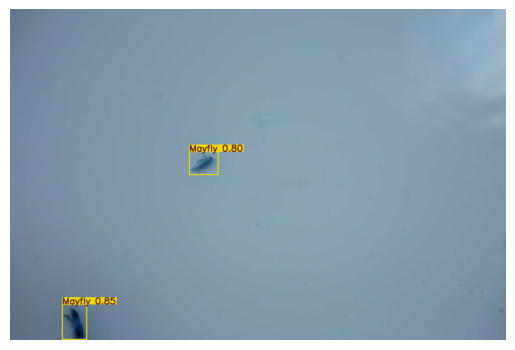

Human Labels:['Mayfly', 'Mayfly']


In [285]:
results = model.predict(source=f"Labeled Data/data/images/{lines[N]}jpg", conf=0.4)
res_plotted = results[0].plot(line_width=6, font_size=2000)
print(f"Number of Bounding Boxes: {len(results[0])}")
plt.axis('off')
plt.imshow(res_plotted)
plt.show()
with open(f'Labeled Data/data/labels/{lines[N]}txt', 'r') as f:
    file = f.read().splitlines()
with open('Labeled Data.yaml', 'r') as f:
    labels = yaml.safe_load(f)
keys = [int(i[0]) for i in file]
labs = [labels['names'][i] for i in keys]
print(f"Human Labels:{labs}")

# Instructions for Loading the Model Without Training 
- Use this code chunk to load the YOLO model.

In [320]:
model = YOLO("runs/detect/train/weights/best.pt")